In [33]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [34]:
#defining state

class state(TypedDict):
    runs: float
    balls: int
    fours: int
    sixes: int
    strike_rate:float
    boundary_percentage: float
    boundary_per_ball: float
    summary: str

In [35]:
#defining strike rate nodes
def strike_rate(state:state):
    """This Function is used to calculate the strike rate of the batsman"""
    strike_rate = (state["runs"] / state["balls"])*100
    
    return {"strike_rate":strike_rate }

In [36]:
#defining boundary percent node
def boundary_per(state:state):
    """This Function is used to calculate the boundary percentage of the batsman"""
    percentage = ((state["fours"]*4 + state["sixes"]*6)/state["runs"])*100
    
    return {"boundary_percentage":percentage}

In [37]:
#defining ball per boundary node
def ball_per_boundary(state:state):
    """This Function is used to calculate the boundary percentage of the batsman"""
    ball_per_boundary_score = (state["fours"]+state["sixes"])/state["balls"]
    
    return {"boundary_per_ball":ball_per_boundary_score}

In [38]:
#defining summary node
def summary(state:state):
    draft = (
        f"Strike Rate: {state['strike_rate']}, "
        f"Boundary Percentage: {state['boundary_percentage']}, "
        f"Boundary Per Ball: {state['boundary_per_ball']}"
    )
    return {"summary": draft}

In [39]:
#defining nodes and edges

graph = StateGraph(state)
graph.add_node("strike_rate", strike_rate)
graph.add_node("boundary percentage", boundary_per)
graph.add_node("balls_per_boundary", ball_per_boundary)
graph.add_node("summary", summary)

graph.add_edge(START, "strike_rate")
graph.add_edge(START, "boundary percentage")
graph.add_edge(START, "balls_per_boundary")

graph.add_edge("strike_rate", "summary")
graph.add_edge("boundary percentage", "summary")
graph.add_edge("balls_per_boundary", "summary")
graph.add_edge("summary", END)

In [40]:
workflow = graph.compile()

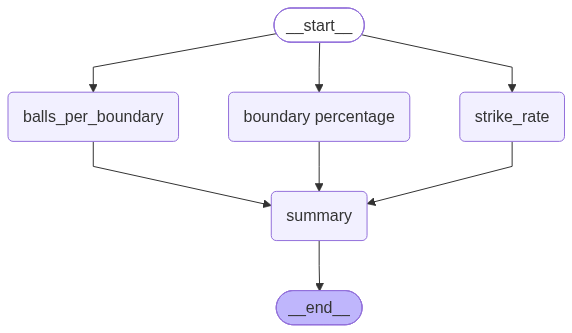

In [41]:
workflow

In [42]:
initial_state = {
    "runs": 80,
    "balls": 50,
    "fours": 8,
    "sixes": 4
}

result = workflow.invoke(initial_state)
print(result)

{'runs': 80, 'balls': 50, 'fours': 8, 'sixes': 4, 'strike_rate': 160.0, 'boundary_percentage': 70.0, 'boundary_per_ball': 0.24, 'summary': 'Strike Rate: 160.0, Boundary Percentage: 70.0, Boundary Per Ball: 0.24'}
